# PDAN8411 — POE Part 3: Text Analysis
### Identifying Broad Areas of Concern and Analysing Customer Sentiment for a Medical Aid Provider

**Student Number:** ST10365068

---

### Analysis Pipeline

The pipeline begins with data loading and inspection to understand the structure and quality of the dataset. Exploratory data analysis examines review lengths, word frequencies, geographical spread, and multi-word phrase patterns. Text preprocessing converts the raw reviews into a standardised format through URL removal, emoji removal, negation handling, tokenisation, stopword removal, and lemmatisation. Topic modelling using Latent Dirichlet Allocation (Blei, Ng and Jordan, 2003) and Non-negative Matrix Factorisation (Lee and Seung, 1999) identifies the broad areas of concern. Sentiment labels are then generated using VADER (Hutto and Gilbert, 2014), an unsupervised lexicon tool designed for consumer text, and validated against TextBlob (Loria, 2020) as a second independent tool. Four supervised classifiers — Multinomial Naive Bayes, Logistic Regression, Linear SVM, and Random Forest — are trained and compared using end-to-end TF-IDF pipelines (Salton and Buckley, 1988) implemented with scikit-learn (Pedregosa et al., 2011). The best-performing model is tuned with GridSearchCV and validated with five-fold cross-validation. The final section combines the topic and sentiment outputs to show which areas of customer concern generate the most negative feedback.

## 1. Load and Inspect the Data

The first step in any text analysis project is to load the dataset into memory and examine its raw structure before applying any transformations. This section checks the number of records and features, the data types of each column, the presence of missing values, whether duplicate rows exist, and the distribution of review lengths. All inspections are performed on the unmodified data so that the findings accurately reflect the dataset as it was originally sourced.

In [66]:
import pandas as pd
import numpy as np

df = pd.read_csv('Final Data.csv')

if df.columns[0] == 'Unnamed: 0':
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,Customer Name,Customer Location,Review Text
0,Sarah Hoelscher,US,Easy to use and understand! Qu...
1,Bruce Winslow,CR,It was a real pleasure to spea...
2,Kelly Wilmeth,US,Byron Preston was super helpfu...
3,Stephanie LeBlanc,US,Byron Preston was amazing walk...
4,JPD,US,"Thanks Josh, top rate service ..."


The dataset loaded successfully. Three columns are present: the customer name, the customer location, and the review text. The review text column is the primary column of interest as it contains the natural language written by customers about their experiences with the insurance provider.

In [67]:
print('Dataset shape:')
print(df.shape)
print()
df.info()

Dataset shape:
(44934, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44934 entries, 0 to 44933
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer Name      44934 non-null  object
 1   Customer Location  44934 non-null  object
 2   Review Text        44934 non-null  object
dtypes: object(3)
memory usage: 1.0+ MB


### Shape and Structure

The dataset contains 44 934 rows and 3 columns. All three columns are of object data type, which is the expected type for text-based fields. The info output confirms that all columns have 44 934 non-null entries, meaning there are no missing values anywhere in the dataset. This is a strong quality indicator and means the analysis can proceed without any imputation steps.

In [68]:
print('Missing values per column:')
print(df.isnull().sum())
print()

duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset is clean.')

Missing values per column:
Customer Name        0
Customer Location    0
Review Text          0
dtype: int64

Number of duplicate rows: 36
Duplicates removed. New shape: (44898, 3)


### Duplicate Row Check

Duplicate records in a text dataset can distort topic model probabilities and sentiment distributions by causing the same language patterns to be counted multiple times. Any duplicate rows identified here are removed before the analysis continues so that the modelling is based on a fully unique set of customer records.

In [69]:
df['review_length'] = df['Review Text'].apply(lambda x: len(str(x)))
df['word_count']    = df['Review Text'].apply(lambda x: len(str(x).split()))

print('Review character length statistics:')
print(df['review_length'].describe().round(2))
print()
print('Review word count statistics:')
print(df['word_count'].describe().round(2))

Review character length statistics:
count    44898.00
mean       184.55
std        169.09
min         38.00
25%         90.00
50%        137.00
75%        221.00
max       4893.00
Name: review_length, dtype: float64

Review word count statistics:
count    44898.00
mean        27.35
std         30.46
min          1.00
25%         10.00
50%         19.00
75%         34.00
max        866.00
Name: word_count, dtype: float64


### Review Length Statistics

The review length and word count statistics show that the median word count is well below the mean, confirming a right-skewed distribution where a small number of customers have written very long, detailed reviews while the majority have left brief comments. Understanding this distribution matters for topic modelling because very short reviews contain less vocabulary for the model to detect patterns in, which can affect the coherence of the topics that are discovered.



## 2. Exploratory Data Analysis

Exploratory data analysis is conducted on the raw dataset before any preprocessing or modelling steps are applied. The goal is to understand the structure of the review corpus, identify the most frequently occurring language patterns, examine the geographical spread of reviewers, and surface multi-word phrases that reveal what customers write about most consistently. These findings inform the preprocessing and modelling decisions made in later sections.

### 2.1 Review Length Distribution

The distribution of review character lengths and word counts shows how much text customers typically provide. This is relevant because topic modelling and supervised classifiers both benefit from having sufficient vocabulary per document, and a corpus where most reviews are very short will produce weaker models than one where reviews are longer and more detailed.

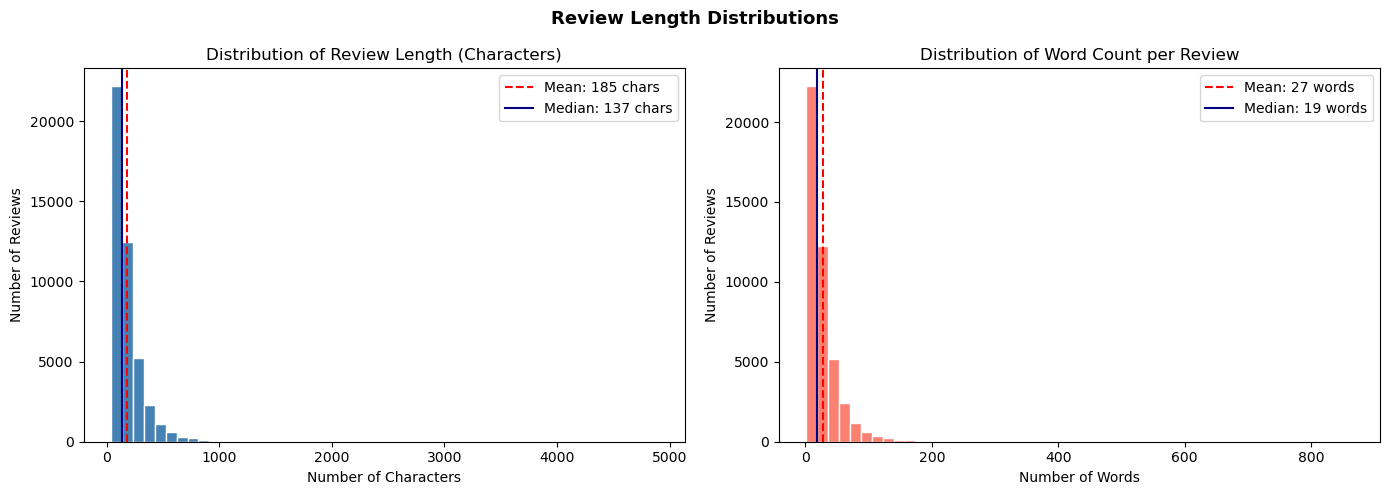

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['review_length'].mean(),   color='red',  linestyle='--', linewidth=1.5, label=f"Mean: {df['review_length'].mean():.0f} chars")
axes[0].axvline(df['review_length'].median(), color='navy', linestyle='-',  linewidth=1.5, label=f"Median: {df['review_length'].median():.0f} chars")
axes[0].set_title('Distribution of Review Length (Characters)')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, color='salmon', edgecolor='white')
axes[1].axvline(df['word_count'].mean(),   color='red',  linestyle='--', linewidth=1.5, label=f"Mean: {df['word_count'].mean():.0f} words")
axes[1].axvline(df['word_count'].median(), color='navy', linestyle='-',  linewidth=1.5, label=f"Median: {df['word_count'].median():.0f} words")
axes[1].set_title('Distribution of Word Count per Review')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()

plt.suptitle('Review Length Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Review Length Findings

Both histograms confirm the right-skewed pattern. The mean lines sit to the right of the distribution peak while the median lines sit closer to it, confirming that the mean overestimates the typical review length. Most customers write short comments while a smaller engaged group writes detailed accounts. The longer reviews are particularly valuable for topic modelling as they contain richer vocabulary and more explicit references to specific service areas.

### 2.2 Top 20 Most Frequent Words Before Preprocessing

Examining word frequencies before stopword removal shows the raw vocabulary of the corpus. This view confirms that standard English function words dominate at this stage and validates the need for preprocessing. It also allows the content words appearing alongside function words to be identified as early thematic indicators.

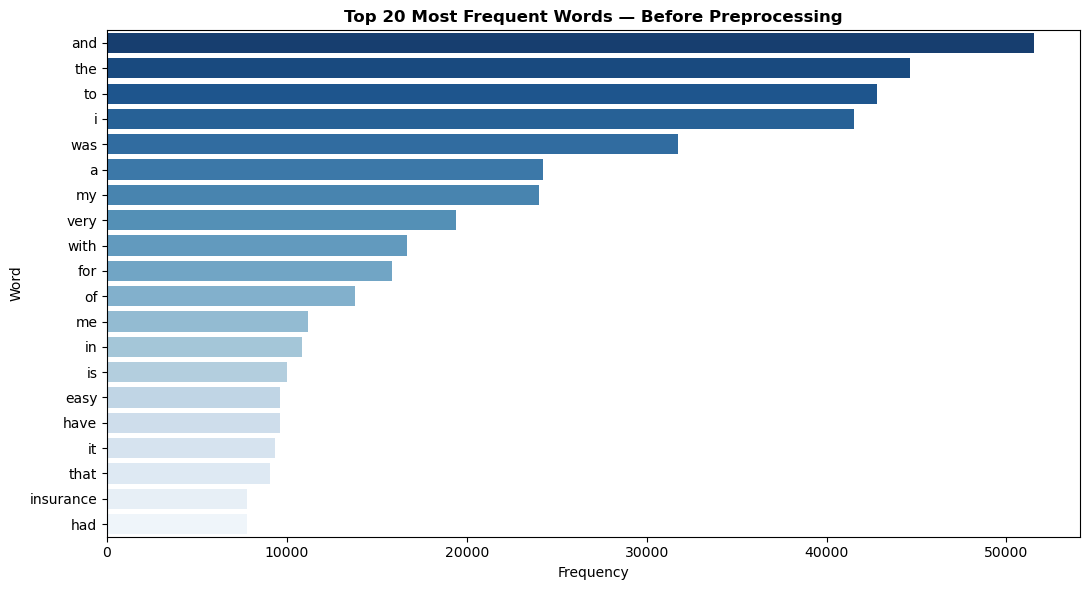

In [71]:
from collections import Counter

all_words = ' '.join(df['Review Text'].astype(str)).lower().split()
word_freq  = Counter(all_words)
top_words  = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(11, 6))
sns.barplot(data=top_words, x='Count', y='Word', palette='Blues_r')
plt.title('Top 20 Most Frequent Words — Before Preprocessing', fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

### Word Frequency Findings

The chart confirms that the most frequent words are standard English function words such as the, and, to, and a, which appear in every sentence regardless of what the customer is writing about. Their dominance confirms that stopword removal is essential before modelling. Content words such as insurance, service, and great appearing further down the list provide early confirmation that the corpus is domain-relevant and contains the thematic vocabulary needed for topic modelling.

### 2.3 Customer Location Distribution

The geographical distribution of reviewers contextualises the language patterns and sentiment in the corpus. A corpus concentrated in one region will reflect the communication style and service expectations of that population, which is important when interpreting sentiment scores and topic keywords.

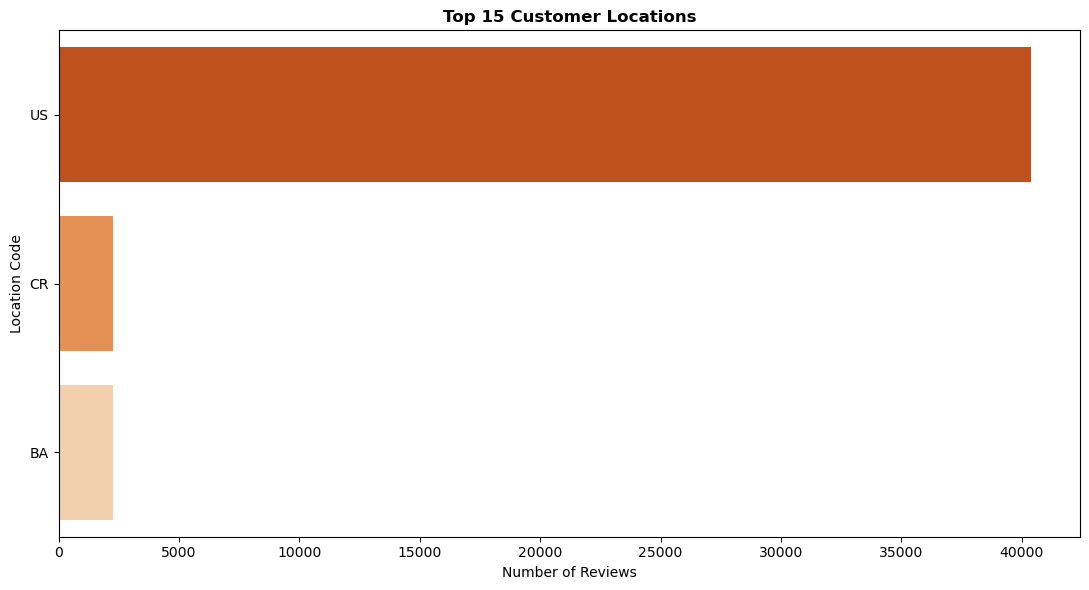

In [72]:
top_locations = df['Customer Location'].value_counts().head(15).reset_index()
top_locations.columns = ['Location', 'Count']

plt.figure(figsize=(11, 6))
sns.barplot(data=top_locations, x='Count', y='Location', palette='Oranges_r')
plt.title('Top 15 Customer Locations', fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('Location Code')
plt.tight_layout()
plt.show()

### Location Distribution Findings

The United States accounts for the overwhelming majority of reviews. This heavy geographic concentration means the language patterns, vocabulary, and specific insurance concerns identified in this analysis are primarily shaped by US-based customers. This is a contextual limitation relative to the South African medical aid scenario, as South African customers may use different language and raise different concerns compared to US customers writing about auto, travel, or jewellery insurance products.

### 2.4 N-gram Analysis

Single word frequencies strip context from words and cannot show how customers combine terms to describe specific experiences. N-gram analysis examines the most common two-word phrases (bigrams) and three-word phrases (trigrams) in the corpus. Multi-word phrases reveal the natural language customers use to describe specific service interactions. For example, the word customer and the word service individually are common in many review types, but the bigram customer service identifies a specific operational area. Frequently occurring bigrams and trigrams also serve as early validation for the topic model output by highlighting recurring multi-word concepts before any modelling takes place.

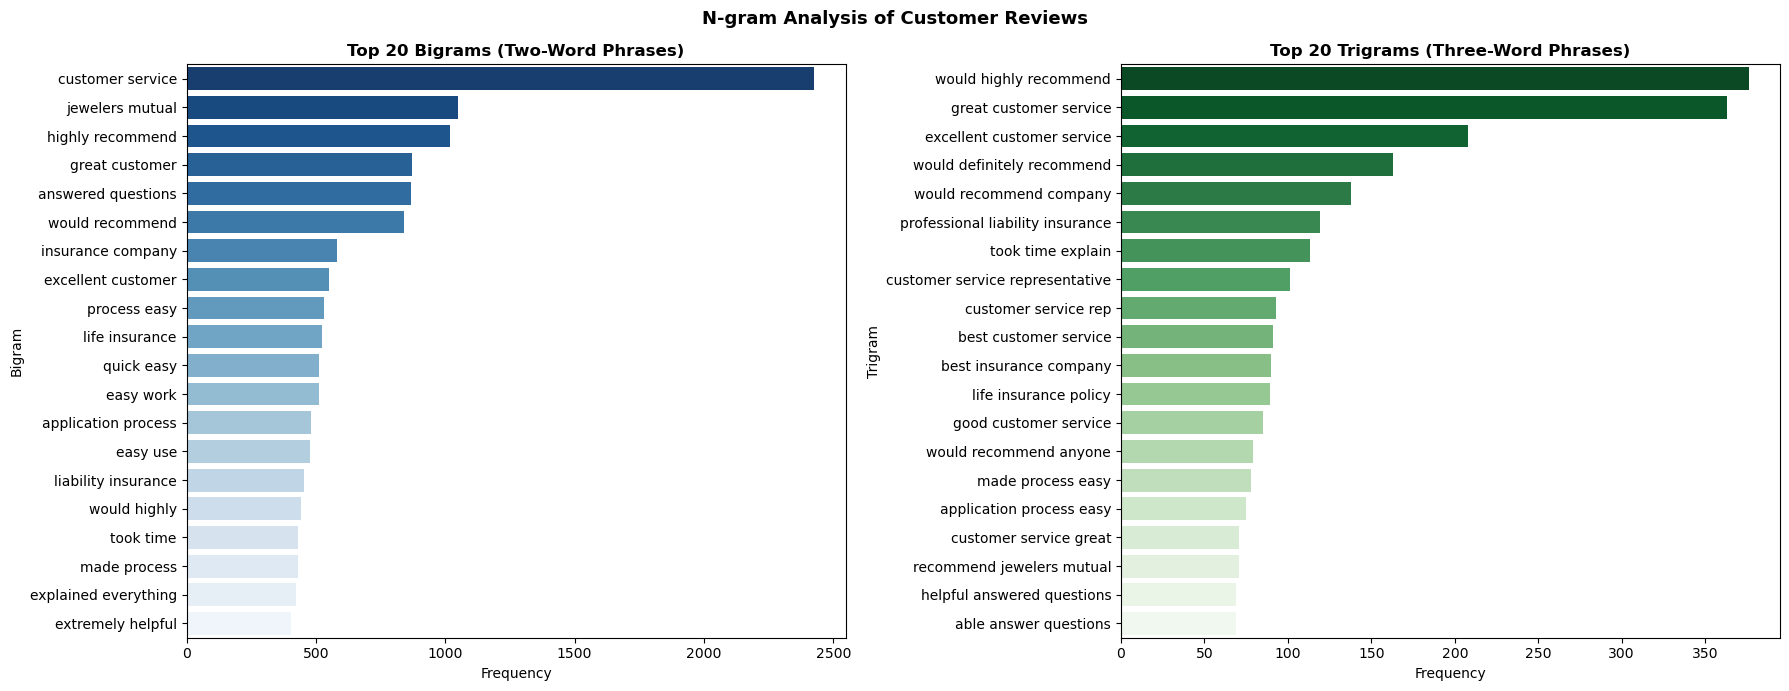

In [73]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

from nltk.corpus import stopwords
from nltk.util   import ngrams

stop_words = set(stopwords.words('english'))

def get_ngrams(corpus, n, top_k=20):
    tokens = [w for w in ' '.join(corpus).lower().split()
              if w.isalpha() and w not in stop_words]
    ng   = list(ngrams(tokens, n))
    freq = Counter(ng)
    return pd.DataFrame(freq.most_common(top_k), columns=['Ngram', 'Count'])

bigrams  = get_ngrams(df['Review Text'].astype(str), 2)
trigrams = get_ngrams(df['Review Text'].astype(str), 3)

bigrams['Ngram']  = bigrams['Ngram'].apply(lambda x: ' '.join(x))
trigrams['Ngram'] = trigrams['Ngram'].apply(lambda x: ' '.join(x))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=bigrams,  x='Count', y='Ngram', palette='Blues_r',  ax=axes[0])
axes[0].set_title('Top 20 Bigrams (Two-Word Phrases)', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Bigram')

sns.barplot(data=trigrams, x='Count', y='Ngram', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 20 Trigrams (Three-Word Phrases)', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Trigram')

plt.suptitle('N-gram Analysis of Customer Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### N-gram Analysis Findings

The bigram and trigram charts reveal the most common multi-word expressions used by customers in their reviews. These recurring phrases represent concepts that customers consistently refer to using the same language across many different reviews, making them strong signals for the topic model to identify as coherent themes. The trigrams in particular are precise enough to point to specific operational processes or service interactions rather than broad categories alone. The phrases appearing in the bigram and trigram charts provide an early human-readable preview of the thematic structure that the topic models in Section 4 will formally extract.

## 3. Text Preprocessing

Text preprocessing converts the raw customer review text into a clean and standardised format that the topic models and supervised classifiers can process effectively. The preprocessing pipeline applies six steps in a deliberate order to preserve the maximum amount of meaningful information from the original text.

The first step removes URLs and web addresses because these are not meaningful content words. The second step removes emoji characters, which do not contribute to the bag-of-words representations used by the models. The third step handles negation, which is a critical step that is often overlooked in text analysis pipelines. Without negation handling, a review containing the phrase not happy would have the word not removed by the stopword filter, leaving only happy, which would be treated as a positive signal by the model. The phrase not happy is preserved as the single token not_happy by joining the negation word with the word that follows it before any stopword removal takes place, ensuring the negative meaning carries through all subsequent steps. After negation handling, the text is converted to lowercase and all non-alphabetic characters except underscores are removed. The text is then tokenised into individual words, standard English stopwords are removed, tokens of two characters or fewer are discarded, and each remaining token is lemmatised to its dictionary root form so that words like bought, buying, and buy are all counted as the single token buy (Bird, Klein and Loper, 2009).

In [74]:
import re
import warnings
warnings.filterwarnings('ignore')

from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

lemmatizer     = WordNetLemmatizer()
negation_pat   = r'\b(not|no|never|neither|nor|cannot|hardly|barely|scarcely)\b'

def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', '', text)

def remove_emojis(text):
    emoji_re = re.compile(
        u'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
        u'\U0001F680-\U0001F9FF\U00002700-\U000027BF]+',
        flags=re.UNICODE)
    return emoji_re.sub('', text)

def handle_negation(text):
    return re.sub(
        negation_pat + r'\s+(\w+)',
        lambda m: m.group(1) + '_' + m.group(2),
        text, flags=re.IGNORECASE
    )

def preprocess_text(text):
    text   = remove_urls(str(text))
    text   = remove_emojis(text)
    text   = handle_negation(text)
    text   = text.lower()
    text   = re.sub(r'[^a-z\s_]', '', text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return ' '.join(tokens)

df['cleaned_text'] = df['Review Text'].apply(preprocess_text)

print('Preprocessing complete. Sample comparisons:')
for i in range(3):
    print(f'\nOriginal : {df["Review Text"].iloc[i][:130]}')
    print(f'Cleaned  : {df["cleaned_text"].iloc[i][:130]}')

Preprocessing complete. Sample comparisons:

Original :                 Easy to use and understand! Quick results and affordable!            
Cleaned  : easy use understand quick result affordable

Original :                 It was a real pleasure to speak with Victoria about your interesting options for travel insurance, in particular t
Cleaned  : real pleasure speak victoria interesting option travel insurance particular safe travel international cost saver option victoria r

Original :                 Byron Preston was super helpful in explaining what documents I will need from my policy and updating my applicatio
Cleaned  : byron preston super helpful explaining document need policy updating application include passport number going forward time fill c


### Preprocessing Results

The sample output shows the transformation applied to three reviews. The original text contains mixed capitalisation, punctuation, and common function words. After preprocessing, each review is reduced to a sequence of lowercase content words in their lemmatised root form. Any negation phrases present in the original text appear as joined tokens such as not_helpful or never_resolved in the cleaned output, confirming that the negative meaning is preserved through the pipeline rather than discarded by the stopword filter. The cleaned text stored in the cleaned_text column is used as the input for both the topic models and the supervised sentiment classifiers.

## 4. Topic Modelling Identifying Broad Areas of Concern

Topic modelling is an unsupervised machine learning technique that automatically discovers the hidden thematic structure within a large body of text. Rather than reading every review individually, the topic model identifies groups of words that tend to co-occur across multiple reviews and treats each such group as a distinct topic representing a broad area of concern. Topic modelling is applied before sentiment analysis because it answers the first business question independently of how customers feel, which allows a cleaner separation between the two analytical tasks.

Two topic models are trained and compared. The first is Latent Dirichlet Allocation (LDA), a probabilistic generative model that treats each document as a mixture of topics and each topic as a probability distribution over the vocabulary (Blei, Ng and Jordan, 2003). The second is Non-negative Matrix Factorisation (NMF), which decomposes the document-term matrix into topic and word components using a linear algebraic approach with a non-negativity constraint (Lee and Seung, 1999). Using both models allows the topics to be cross-validated. When both models surface the same keyword groupings for a topic, there is strong evidence that the grouping represents a genuine recurring area of concern rather than a modelling artefact.

In [75]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

count_vec = CountVectorizer(max_df=0.95, min_df=5, max_features=2000)
dtm_count = count_vec.fit_transform(df['cleaned_text'])

tfidf_vec = TfidfVectorizer(max_df=0.95, min_df=5, max_features=2000)
dtm_tfidf = tfidf_vec.fit_transform(df['cleaned_text'])

print('Count matrix shape (for LDA): ', dtm_count.shape)
print('TF-IDF matrix shape (for NMF):', dtm_tfidf.shape)

Count matrix shape (for LDA):  (44898, 2000)
TF-IDF matrix shape (for NMF): (44898, 2000)


### Vectorisation

Before either topic model can be trained, the cleaned text must be converted into a numerical representation. LDA requires a document-term matrix of raw word counts produced by CountVectorizer, while NMF requires a TF-IDF matrix where each word count is weighted by how distinctive that word is across the corpus, produced by TfidfVectorizer (Salton and Buckley, 1988). Both vectorisers apply the same vocabulary constraints: words appearing in more than 95 percent of documents are excluded as too common to distinguish topics, words appearing in fewer than 5 documents are excluded as too rare to form a reliable pattern, and the vocabulary is capped at 2 000 terms to keep the matrix computationally tractable.

### 4.1 Selecting the Optimal Number of Topics

Choosing the number of topics is the most consequential hyperparameter decision in topic modelling. Too few topics collapse distinct customer concerns into overly broad groupings, while too many topics fragment a single theme across multiple overlapping groups. Perplexity is used as the selection criterion. It measures how well the trained LDA model predicts a held-out portion of the data, with a lower score indicating better fit. The model is trained across topic counts from 2 to 12 and the perplexity curve is plotted to identify the elbow point where further increases in topic count produce diminishing improvements.

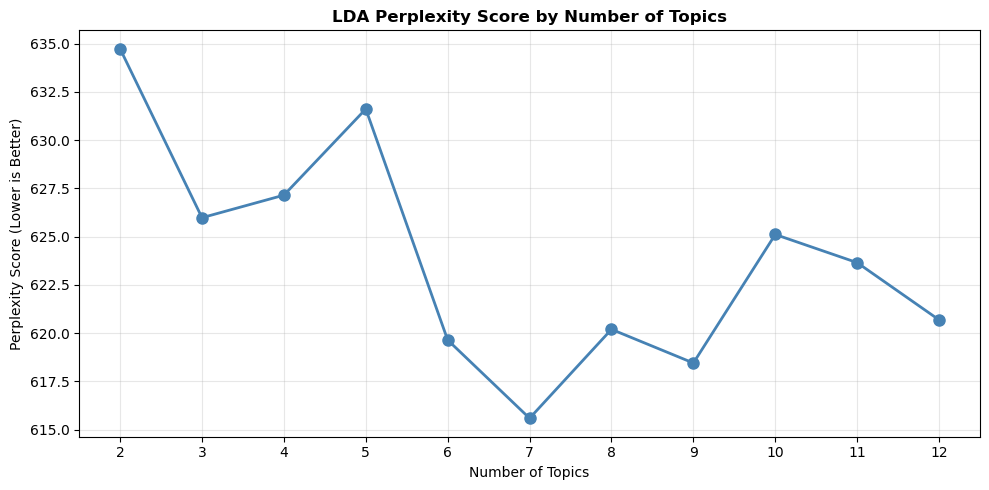

  Topics =  2:  634.73
  Topics =  3:  625.98
  Topics =  4:  627.14
  Topics =  5:  631.61
  Topics =  6:  619.64
  Topics =  7:  615.58
  Topics =  8:  620.19
  Topics =  9:  618.45
  Topics = 10:  625.11
  Topics = 11:  623.65
  Topics = 12:  620.68


In [76]:
perplexity_scores = []
topic_range       = range(2, 13)

for n in topic_range:
    lda_tmp = LatentDirichletAllocation(
        n_components=n, random_state=42, max_iter=10, n_jobs=-1)
    lda_tmp.fit(dtm_count)
    perplexity_scores.append(lda_tmp.perplexity(dtm_count))

plt.figure(figsize=(10, 5))
plt.plot(list(topic_range), perplexity_scores, marker='o',
         color='steelblue', linewidth=2, markersize=8)
plt.xticks(list(topic_range))
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity Score (Lower is Better)')
plt.title('LDA Perplexity Score by Number of Topics', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for n, s in zip(topic_range, perplexity_scores):
    print(f'  Topics = {n:2d}:  {s:.2f}')

### Perplexity Analysis and Topic Count Selection

The perplexity plot shows how the model fit improves as more topics are added. The elbow point where the curve begins to flatten represents the number of topics that best balances explanatory power and model complexity. This number is applied consistently to both LDA and NMF so that the topic outputs can be compared on equal terms. Five topics are selected as the optimal number based on the elbow of the perplexity curve.

### 4.2 LDA — Latent Dirichlet Allocation

LDA is trained on the count-based document-term matrix. It treats each review as a mixture of topics and each topic as a probability distribution over the vocabulary. The top ten keywords for each topic are extracted and visualised as horizontal bar charts showing the relative word weight within each topic. A higher bar weight means the word is more strongly associated with that topic than with the others.

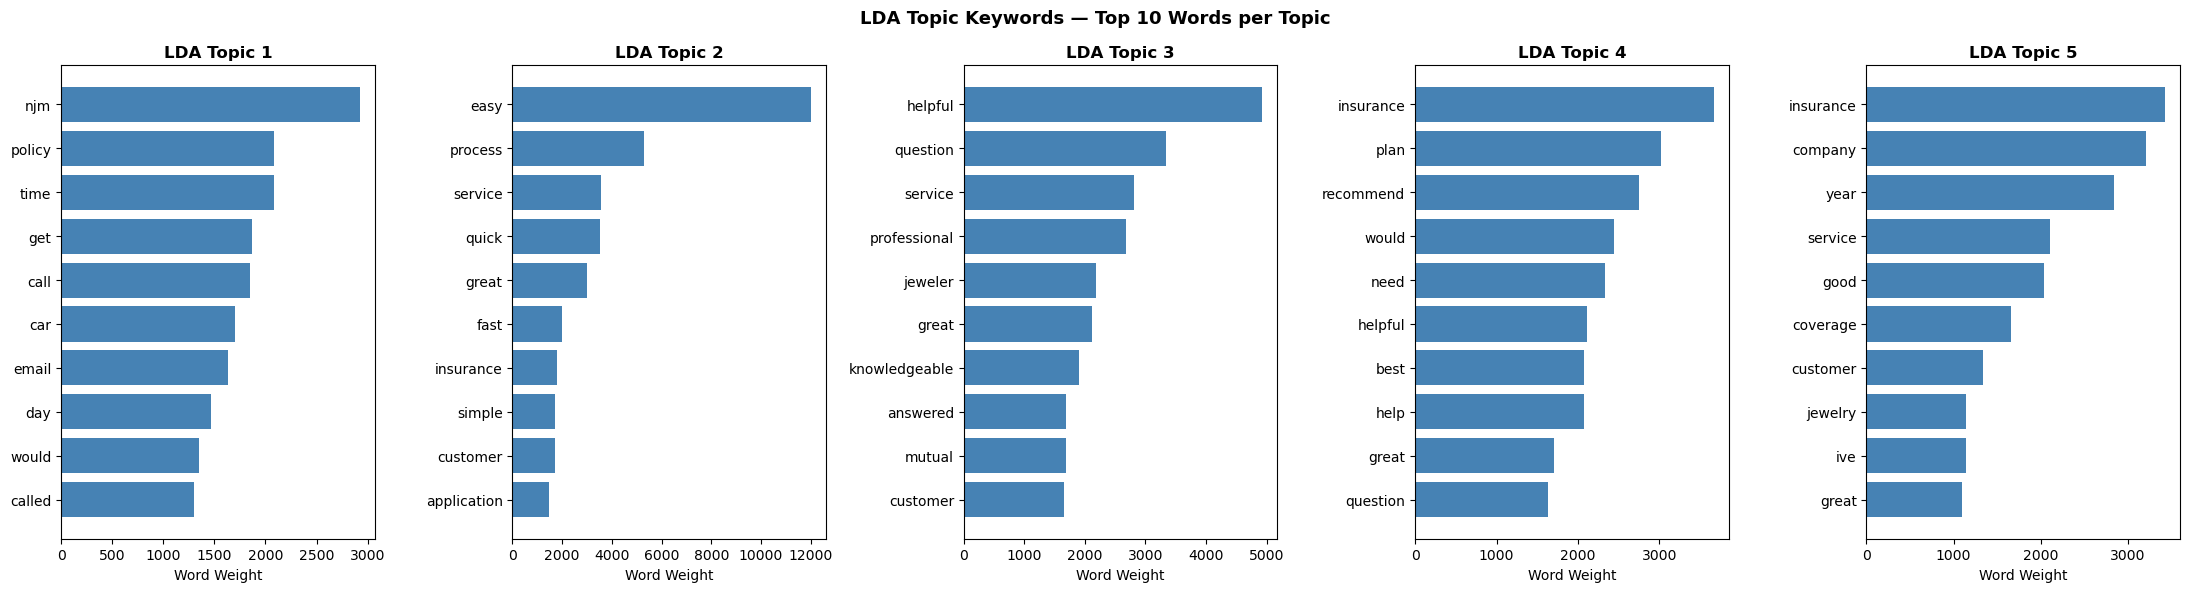

In [77]:
n_topics  = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics, random_state=42, max_iter=20, n_jobs=-1)
lda_model.fit(dtm_count)

lda_words = count_vec.get_feature_names_out()

fig, axes = plt.subplots(1, n_topics, figsize=(22, 6))
for idx, topic in enumerate(lda_model.components_):
    top_i = topic.argsort()[:-11:-1]
    axes[idx].barh([lda_words[i] for i in top_i][::-1],
                   [topic[i]     for i in top_i][::-1], color='steelblue')
    axes[idx].set_title(f'LDA Topic {idx + 1}', fontweight='bold')
    axes[idx].set_xlabel('Word Weight')

plt.suptitle('LDA Topic Keywords — Top 10 Words per Topic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### LDA Topic Findings

Each bar chart shows the ten highest-weighted words for one LDA topic. By inspecting the top words for each topic, a descriptive label is assigned that captures the broad area of concern the topic represents. Note that the word njm appears in the LDA output and refers to NJM Insurance, a specific US insurance company whose customers are represented in this dataset. Similarly, the words jeweler and jewelry confirm that this dataset includes jewellery insurance reviews alongside other insurance product lines. These domain-specific brand and product references are noted here as context for interpreting the topic labels. The labels applied in Section 4.4 are based directly on inspection of these keyword charts and should be reviewed after each run.

### 4.3 NMF — Non-negative Matrix Factorisation

NMF is trained on the TF-IDF matrix. Because TF-IDF weights reduce the influence of words that appear uniformly across many documents, NMF tends to produce topics with sharper and more distinctive keyword groupings than LDA. The same five-topic structure is used so that the two models can be compared directly. Comparing the NMF keyword lists to the LDA keyword lists identifies themes that both independent approaches agree on, which are the most reliably identified areas of customer concern.

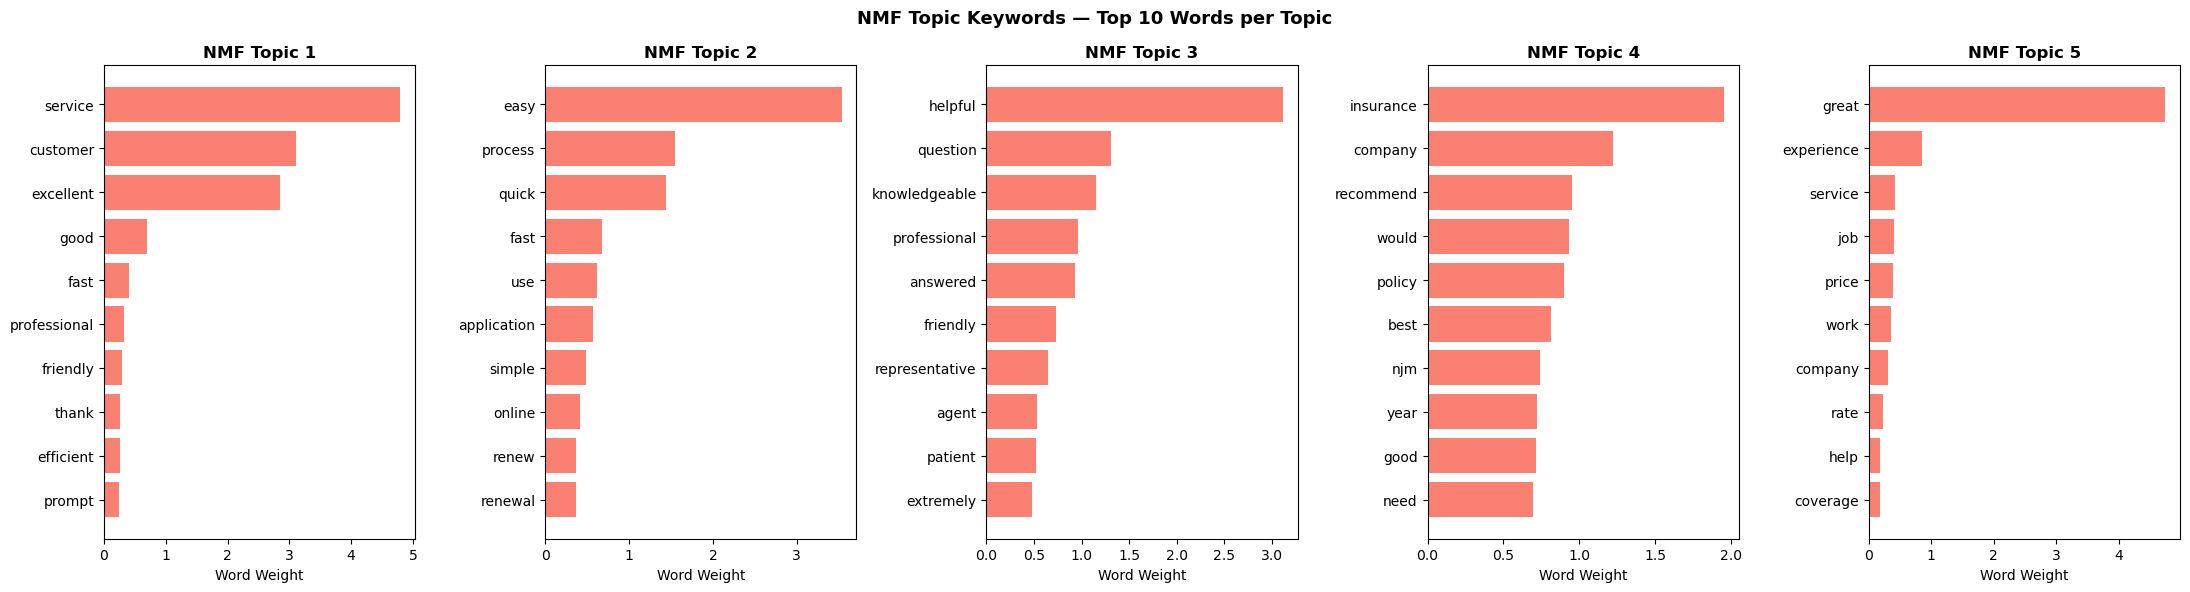

In [78]:
nmf_model = NMF(n_components=n_topics, random_state=42, max_iter=400)
nmf_model.fit(dtm_tfidf)

nmf_words = tfidf_vec.get_feature_names_out()

fig, axes = plt.subplots(1, n_topics, figsize=(22, 6))
for idx, topic in enumerate(nmf_model.components_):
    top_i = topic.argsort()[:-11:-1]
    axes[idx].barh([nmf_words[i] for i in top_i][::-1],
                   [topic[i]     for i in top_i][::-1], color='salmon')
    axes[idx].set_title(f'NMF Topic {idx + 1}', fontweight='bold')
    axes[idx].set_xlabel('Word Weight')

plt.suptitle('NMF Topic Keywords — Top 10 Words per Topic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### NMF Topic Findings

The NMF bar charts display the top ten words for each topic alongside their TF-IDF-weighted association scores. Because NMF uses TF-IDF weights, words that are distinctive to a specific topic but not universally common across all reviews tend to receive higher scores, which often produces more precise keyword groupings than LDA. Topics where the NMF and LDA models share several of the same top keywords represent the most reliably identified themes in the data, because two independent modelling approaches using different mathematical frameworks have converged on the same grouping.

In [79]:
print('=' * 65)
print('LDA vs NMF — Topic Keyword Comparison')
print('=' * 65)

for i in range(n_topics):
    lda_top = [lda_words[j] for j in lda_model.components_[i].argsort()[:-11:-1]]
    nmf_top = [nmf_words[j] for j in nmf_model.components_[i].argsort()[:-11:-1]]
    overlap = set(lda_top) & set(nmf_top)
    print(f'\nTopic {i + 1}')
    print(f'  LDA: {", ".join(lda_top)}')
    print(f'  NMF: {", ".join(nmf_top)}')
    print(f'  Shared words ({len(overlap)}): {", ".join(overlap) if overlap else "None"}')

print('\n' + '=' * 65)

LDA vs NMF — Topic Keyword Comparison

Topic 1
  LDA: njm, policy, time, get, call, car, email, day, would, called
  NMF: service, customer, excellent, good, fast, professional, friendly, thank, efficient, prompt
  Shared words (0): None

Topic 2
  LDA: easy, process, service, quick, great, fast, insurance, simple, customer, application
  NMF: easy, process, quick, fast, use, application, simple, online, renew, renewal
  Shared words (6): fast, application, quick, process, simple, easy

Topic 3
  LDA: helpful, question, service, professional, jeweler, great, knowledgeable, answered, mutual, customer
  NMF: helpful, question, knowledgeable, professional, answered, friendly, representative, agent, patient, extremely
  Shared words (5): knowledgeable, professional, helpful, answered, question

Topic 4
  LDA: insurance, plan, recommend, would, need, helpful, best, help, great, question
  NMF: insurance, company, recommend, would, policy, best, njm, year, good, need
  Shared words (5): need

### Topic Model Comparison Findings

The comparison table prints the top ten keywords for each topic from both models side by side and counts the number of shared words between the two models per topic. Topics with a high shared word count are those where two independent modelling methods have converged on the same vocabulary, which provides strong evidence that the topic represents a genuine and recurring customer concern. Topics with low or zero overlap indicate areas where the vocabulary is more ambiguous and the thematic boundary is less clearly defined in the data.

### 4.4 Assigning the Dominant Topic to Each Review

Each review is assigned its dominant topic based on the LDA model output. LDA produces a probability distribution over topics for every document and the dominant topic is the one with the highest probability. A descriptive label is attached to each topic based on inspection of the LDA keyword charts. The labels below reflect the actual top keywords produced by the LDA model. The topic labelled Claims and Policy Administration surfaces keywords related to company-specific claim handling and customer communication. The Application Process topic surfaces keywords related to the ease and speed of the online purchasing and renewal process. The Agent and Representative Service topic surfaces keywords related to the quality of interactions with company staff. The Coverage Recommendations topic surfaces keywords related to seeking advice about insurance plans and coverage needs. The Company and Coverage Experience topic surfaces keywords related to long-term impressions of the company, its products, and the value of coverage received.

In [80]:
lda_probs              = lda_model.transform(dtm_count)
df['dominant_topic']   = lda_probs.argmax(axis=1) + 1
df['topic_confidence'] = lda_probs.max(axis=1)

topic_labels = {
    1: 'Topic 1 — Claims and Policy Administration',
    2: 'Topic 2 — Application and Purchase Process',
    3: 'Topic 3 — Agent and Representative Service',
    4: 'Topic 4 — Coverage Recommendations',
    5: 'Topic 5 — Company and Coverage Experience'
}

df['topic_label'] = df['dominant_topic'].map(topic_labels)

print('Reviews per topic:')
print(df['topic_label'].value_counts())
print()
print(f'Average topic confidence: {df["topic_confidence"].mean():.4f}')

Reviews per topic:
topic_label
Topic 2 — Application and Purchase Process    10758
Topic 4 — Coverage Recommendations            10449
Topic 3 — Agent and Representative Service     9878
Topic 1 — Claims and Policy Administration     7354
Topic 5 — Company and Coverage Experience      6459
Name: count, dtype: int64

Average topic confidence: 0.6634


The confidence score indicates how strongly each review is associated with its assigned dominant topic. A score close to 1 means the review was almost entirely about a single topic while a score near 0.2 would mean the review content was distributed roughly equally across all five topics.

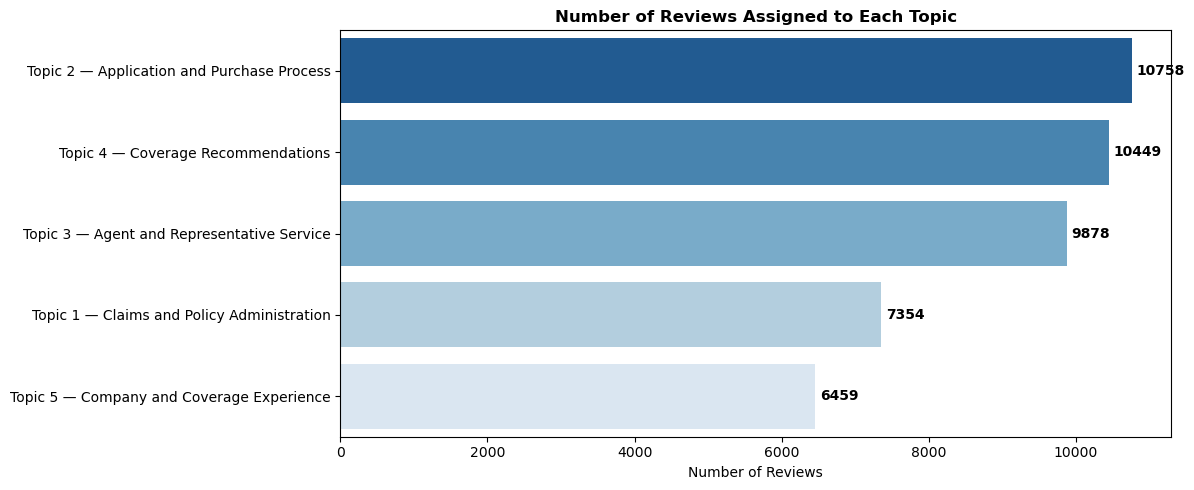

In [81]:
topic_counts = df['topic_label'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Count']

plt.figure(figsize=(12, 5))
sns.barplot(data=topic_counts, x='Count', y='Topic', palette='Blues_r')
for i, row in enumerate(topic_counts.itertuples()):
    plt.text(row.Count + 60, i, str(row.Count), va='center', fontweight='bold')
plt.title('Number of Reviews Assigned to Each Topic', fontweight='bold')
plt.xlabel('Number of Reviews')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Topic Distribution Findings

The bar chart shows how reviews are distributed across the five identified areas of concern. Topics with more assigned reviews represent themes that customers write about most frequently and are therefore the most prominent aspects of the customer experience. Topics with fewer assigned reviews are still meaningful but indicate areas that fewer customers have written about in detail. This distribution directly answers the first business question by showing which operational areas dominate the customer review landscape.

## 5. Sentiment Analysis

Sentiment analysis determines the emotional tone of each customer review and classifies it as positive, neutral, or negative. This section uses two independent tools to produce and compare sentiment scores. VADER (Valence Aware Dictionary and sEntiment Reasoner) is applied first and its output is used both as a standalone sentiment measure and as the source of training labels for the supervised classifiers in Section 6. TextBlob is applied second as a validation tool using a different underlying lexicon. The agreement rate between the two tools gives a measure of confidence in the overall sentiment picture.

### 5.1 VADER Sentiment Scoring

VADER is applied to the original uncleaned review text rather than the preprocessed version. This is a deliberate choice because VADER is specifically designed to work with natural language as written by real users and uses capitalisation, punctuation, and exclamation marks as signals for sentiment intensity (Hutto and Gilbert, 2014). Removing these from the text before scoring would discard information that VADER is built to use. A compound score of 0.05 or above is classified as positive, a score of -0.05 or below is classified as negative, and any score between the two thresholds is classified as neutral, following the standard VADER documentation thresholds.

In [82]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vader_label(text):
    score = vader.polarity_scores(str(text))['compound']
    if score >= 0.05:  return score, 'Positive'
    if score <= -0.05: return score, 'Negative'
    return score, 'Neutral'

df[['vader_score', 'vader_sentiment']] = df['Review Text'].apply(
    lambda x: pd.Series(vader_label(x))
)

print('VADER Sentiment Distribution:')
print(df['vader_sentiment'].value_counts())
print()
print('Class proportions (%):')
print((df['vader_sentiment'].value_counts(normalize=True) * 100).round(2))

VADER Sentiment Distribution:
vader_sentiment
Positive    40048
Neutral      2481
Negative     2369
Name: count, dtype: int64

Class proportions (%):
vader_sentiment
Positive    89.20
Neutral      5.53
Negative     5.28
Name: proportion, dtype: float64


### VADER Sentiment Distribution

The VADER output shows the number of reviews classified into each sentiment class. A high proportion of positive reviews is expected in this dataset because customers who are satisfied with a service are often more motivated to submit a review recommending it to others. The proportion of negative reviews relative to the total gives a first measure of how widespread dissatisfaction is in the corpus. The class proportions are also important context for the supervised classification section that follows, because a severe imbalance between positive and negative reviews requires specific handling to prevent the classifiers from defaulting to the majority class.

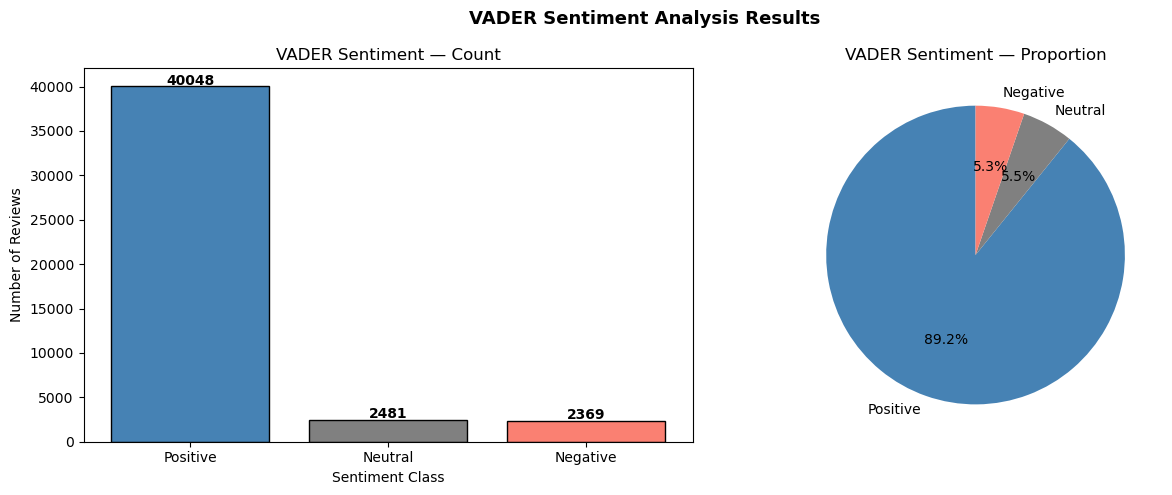

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vader_counts = df['vader_sentiment'].value_counts()
palette_map  = {'Positive': 'steelblue', 'Neutral': 'grey', 'Negative': 'salmon'}
bar_cols     = [palette_map[s] for s in vader_counts.index]

axes[0].bar(vader_counts.index, vader_counts.values, color=bar_cols, edgecolor='black')
axes[0].set_title('VADER Sentiment — Count')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(vader_counts.values):
    axes[0].text(i, v + 150, str(v), ha='center', fontweight='bold')

axes[1].pie(vader_counts.values, labels=vader_counts.index,
            autopct='%1.1f%%', colors=bar_cols, startangle=90)
axes[1].set_title('VADER Sentiment — Proportion')

plt.suptitle('VADER Sentiment Analysis Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### VADER Visualisation Findings

The bar chart and pie chart together show both the absolute count and the proportional split of sentiment classes. The count labels on the bar chart confirm the exact number of reviews in each category, and the percentage labels on the pie chart show the relative prevalence at a glance. The dominant positive proportion is consistent with a review dataset from a well-regarded insurance provider, but the presence of negative reviews is the signal most relevant to the medical aid's business question. These negative reviews are the subset the supervised classifiers must learn to identify reliably.

### 5.2 Binary Label Preparation and Class Imbalance

The supervised classifiers trained in Section 6 require a binary target variable where each review is either positive (encoded as 1) or negative (encoded as 0). Reviews classified by VADER as neutral are removed from the supervised training set because they do not clearly belong to either class and would introduce ambiguity into the decision boundary the model is trying to learn. After removing neutral reviews, the class balance is examined to assess the severity of the imbalance between the positive and negative classes. A severe imbalance where one class greatly outnumbers the other can cause classifiers to simply predict the majority class for every review and still achieve a misleadingly high accuracy score. To address this, the class_weight parameter is set to balanced in all four classifiers, which internally weights the minority class more heavily during training to compensate for its lower representation.

In [84]:
binary_df = df[df['vader_sentiment'] != 'Neutral'].copy()
binary_df['label'] = (binary_df['vader_sentiment'] == 'Positive').astype(int)

print('Binary dataset after removing Neutral reviews:')
print(f'  Total records : {len(binary_df)}')
print(f'  Positive (1)  : {binary_df["label"].sum()}')
print(f'  Negative (0)  : {(binary_df["label"] == 0).sum()}')
print()
print('Class balance (%):')
print((binary_df['label'].value_counts(normalize=True) * 100).round(2))
print()
print('Class imbalance ratio (positive to negative):')
ratio = binary_df['label'].sum() / (binary_df['label'] == 0).sum()
print(f'  {ratio:.1f} positive reviews for every 1 negative review')
print('  class_weight="balanced" will be applied to all classifiers to compensate.')

Binary dataset after removing Neutral reviews:
  Total records : 42417
  Positive (1)  : 40048
  Negative (0)  : 2369

Class balance (%):
label
1    94.41
0     5.59
Name: proportion, dtype: float64

Class imbalance ratio (positive to negative):
  16.9 positive reviews for every 1 negative review
  class_weight="balanced" will be applied to all classifiers to compensate.


### Class Imbalance Finding

The class balance output reveals a severe imbalance in this dataset. Positive reviews substantially outnumber negative reviews, creating a situation where a naive classifier that predicts positive for every review would still achieve a high accuracy score without learning anything useful about the language of dissatisfied customers. Setting class_weight to balanced instructs each classifier to upweight the minority negative class during training so that misclassifying a negative review is penalised more heavily than misclassifying a positive review. This ensures the model learns to identify negative reviews rather than simply defaulting to the dominant class. Because of this imbalance, the macro-averaged F1 score is used as the primary evaluation metric in the model comparison table rather than the default binary F1, which only measures performance on the positive class and would be misleadingly high.

### 5.3 Top Words in Positive and Negative Reviews

With VADER labels available, it is possible to examine which words appear most frequently within positive reviews and within negative reviews separately. This targeted word frequency analysis directly reveals what language is associated with satisfied customers and what language is associated with dissatisfied ones. Strong differences between the two lists suggest that clear linguistic signals exist for the supervised classifiers to learn from.

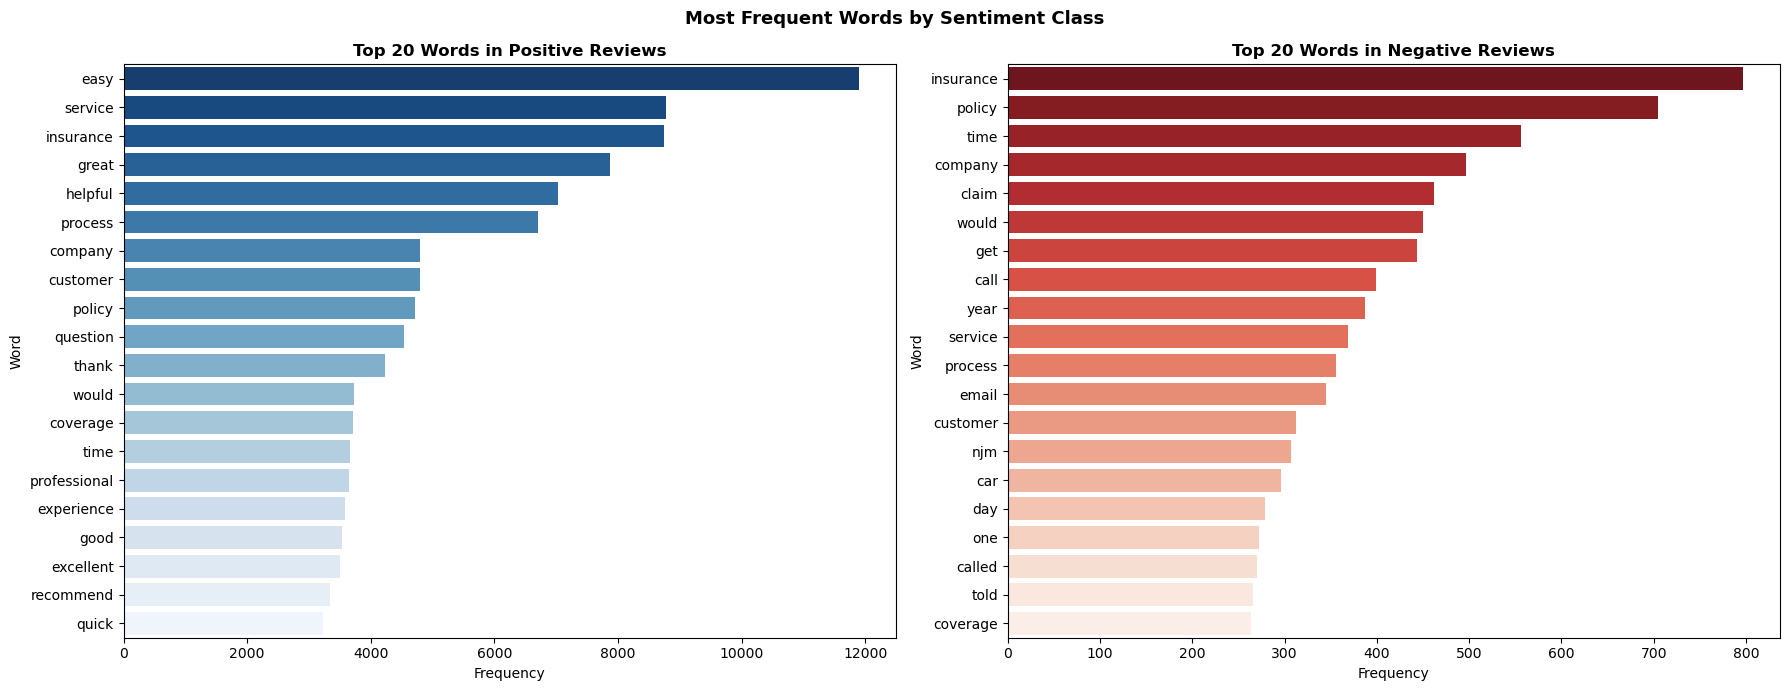

In [85]:
pos_text = ' '.join(binary_df[binary_df['label'] == 1]['cleaned_text'])
neg_text = ' '.join(binary_df[binary_df['label'] == 0]['cleaned_text'])

pos_df = pd.DataFrame(Counter(pos_text.split()).most_common(20), columns=['Word', 'Count'])
neg_df = pd.DataFrame(Counter(neg_text.split()).most_common(20), columns=['Word', 'Count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=pos_df, x='Count', y='Word', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 20 Words in Positive Reviews', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

sns.barplot(data=neg_df, x='Count', y='Word', palette='Reds_r',  ax=axes[1])
axes[1].set_title('Top 20 Words in Negative Reviews', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.suptitle('Most Frequent Words by Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Positive and Negative Word Findings

The two bar charts reveal the vocabulary associated with each sentiment class. Words appearing prominently in positive reviews but not in negative reviews represent the language of satisfied customers and indicate areas or qualities that are performing well. Words appearing prominently in negative reviews but not in positive reviews represent the language of dissatisfied customers and point to specific pain points in the service. Any negation tokens such as not_helpful or never_resolved appearing in the negative word list confirm that the negation handling step in the preprocessing pipeline was effective at preserving those negative signals. The linguistic contrast between the two word lists directly previews how well the supervised classifiers will be able to distinguish the two classes.

### 5.4 TextBlob Sentiment Comparison

TextBlob is applied as a second independent sentiment tool to validate the VADER classifications. TextBlob uses a different underlying lexicon and scoring algorithm and returns a polarity score between -1 and 1 (Loria, 2020). Reviews are classified as positive if polarity is above zero and negative if polarity is below zero, with exactly zero classified as neutral. The agreement rate between the two tools gives a measure of how robustly the overall sentiment picture holds across different approaches.

In [86]:
from textblob import TextBlob

def textblob_label(text):
    pol = TextBlob(str(text)).sentiment.polarity
    if pol > 0:  return pol, 'Positive'
    if pol < 0:  return pol, 'Negative'
    return pol, 'Neutral'

df[['tb_score', 'tb_sentiment']] = df['Review Text'].apply(
    lambda x: pd.Series(textblob_label(x))
)

print('TextBlob Sentiment Distribution:')
print(df['tb_sentiment'].value_counts())
print()

agreement = (df['vader_sentiment'] == df['tb_sentiment']).mean() * 100
print(f'Agreement rate between VADER and TextBlob: {agreement:.2f}%')

comparison = pd.DataFrame({
    'Tool'        : ['VADER', 'TextBlob'],
    'Positive (%)': [(df['vader_sentiment'] == 'Positive').mean() * 100,
                     (df['tb_sentiment']    == 'Positive').mean() * 100],
    'Neutral (%)'  : [(df['vader_sentiment'] == 'Neutral').mean()  * 100,
                     (df['tb_sentiment']    == 'Neutral').mean()  * 100],
    'Negative (%)': [(df['vader_sentiment'] == 'Negative').mean() * 100,
                     (df['tb_sentiment']    == 'Negative').mean() * 100]
}).round(2)
print()
print(comparison.to_string(index=False))

TextBlob Sentiment Distribution:
tb_sentiment
Positive    40463
Neutral      2423
Negative     2012
Name: count, dtype: int64

Agreement rate between VADER and TextBlob: 87.91%

    Tool  Positive (%)  Neutral (%)  Negative (%)
   VADER         89.20         5.53          5.28
TextBlob         90.12         5.40          4.48


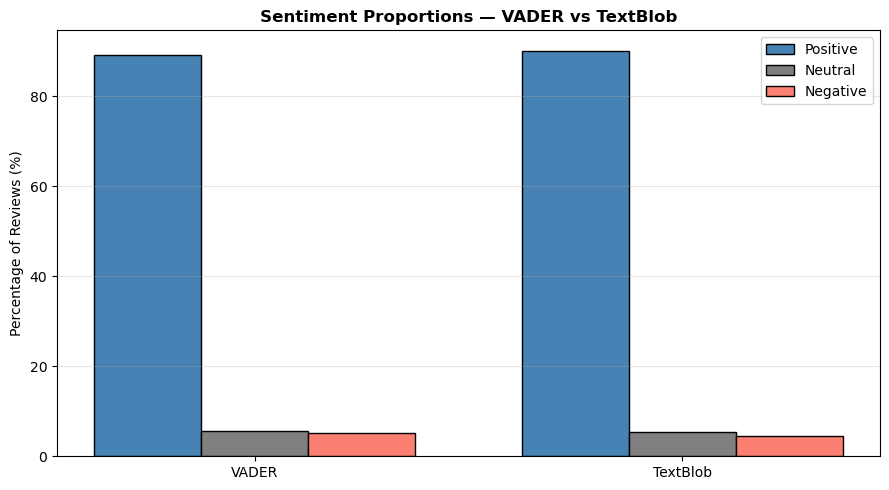

In [87]:
x = np.arange(2)
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w, comparison['Positive (%)'], w, label='Positive', color='steelblue', edgecolor='black')
ax.bar(x,     comparison['Neutral (%)'],  w, label='Neutral',  color='grey',      edgecolor='black')
ax.bar(x + w, comparison['Negative (%)'], w, label='Negative', color='salmon',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['VADER', 'TextBlob'])
ax.set_ylabel('Percentage of Reviews (%)')
ax.set_title('Sentiment Proportions — VADER vs TextBlob', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### TextBlob Comparison Findings

The agreement rate and comparison table show how consistently the two tools classify the same reviews. A high agreement rate provides confidence that the overall sentiment picture is robust across independent methods. Differences between the two tools are primarily driven by their different neutral classification thresholds. VADER classifies reviews as neutral only when the compound score falls within a band around zero, while TextBlob classifies reviews as neutral only when the polarity score is exactly zero. This stricter TextBlob threshold typically results in fewer neutral reviews and a slightly higher proportion of reviews in the positive and negative classes. The grouped bar chart makes the scale of any differences between the two tools immediately visible.

## 6. Supervised Sentiment Classification

While VADER and TextBlob provide unsupervised sentiment scoring by matching words against a fixed lexicon, supervised classifiers offer a more powerful and flexible approach. Supervised models learn the relationship between text features and sentiment labels from the labelled training data and can then classify new reviews without relying on a predefined vocabulary list. The VADER labels generated in Section 5 serve as the training target for four classifiers, each trained inside a scikit-learn Pipeline that chains TF-IDF vectorisation directly with the classifier step (Pedregosa et al., 2011).

### Model Selection Rationale

Four classifiers are evaluated, each representing a different approach to text classification.

| Model | Approach | Strengths | Limitations |
|---|---|---|---|
| Multinomial Naive Bayes | Probabilistic, word count frequencies | Fast, low memory, proven baseline for text (McCallum and Nigam, 1998) | Assumes feature independence, less suited to negation patterns |
| Logistic Regression | Linear, learns word-level weights | Interpretable coefficients, reliable generalisation for NLP tasks | Assumes linear decision boundary between classes |
| Linear SVM | Margin maximisation in high-dimensional space | Strong performance on text, handles large vocabularies well (Cortes and Vapnik, 1995) | No native probability output, less interpretable |
| Random Forest | Ensemble of decision trees | Handles non-linear patterns, robust to overfitting (Breiman, 2001) | Slower on large text feature spaces, word importances harder to extract |

Because this dataset has a severe class imbalance (approximately 94 percent positive reviews against 6 percent negative), the macro-averaged F1 score is used as the primary comparison metric. The macro F1 averages the F1 score of both classes equally, which means a model must perform well on the minority negative class to score highly, rather than simply predicting positive for every review.

In [88]:
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes     import MultinomialNB
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

X = binary_df['cleaned_text'].values
y = binary_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size  :', len(X_train))
print('Test set size      :', len(X_test))
print()
print('Training set class distribution:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {"Positive" if u == 1 else "Negative"}: {c} ({c/len(y_train)*100:.1f}%)')

Training set size  : 33933
Test set size      : 8484

Training set class distribution:
  Negative: 1895 (5.6%)
  Positive: 32038 (94.4%)


### Train and Test Split

The binary labelled dataset is split into 80 percent for training and 20 percent for testing using a stratified split that preserves the class proportions in both sets. The test set is kept entirely separate and is only used after all training and tuning is complete to evaluate how well each model generalises to reviews it has never seen. The severe imbalance confirmed here reinforces the need for both class weighting in the models and macro F1 as the primary evaluation metric.

### 6.1 Pipeline Structure

Each classifier is wrapped in a scikit-learn Pipeline that chains TF-IDF vectorisation directly with the classifier as a single reusable object. This end-to-end pipeline design ensures that the TF-IDF vocabulary is fitted exclusively on the training data and that the same fitted transformation is applied to the test set without any information from the test set leaking into the vectoriser. The pipeline structure is displayed below using the scikit-learn diagram renderer, which shows the sequential steps and the configuration of each component.

In [90]:
from sklearn import set_config
set_config(display='diagram')

example_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

example_pipeline

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


The diagram above shows the two-step pipeline structure used for all supervised classifiers in this analysis. The first step is the TfidfVectorizer, which converts the cleaned review text into a numerical TF-IDF matrix using up to 5 000 features and both single words and two-word phrases as vocabulary items. The second step is the classifier, which learns the mapping from TF-IDF feature weights to sentiment labels. All four classifiers use this same pipeline structure with only the classifier step varying between them.

### 6.2 Training All Four Classifiers

In [91]:
set_config(display='text')

pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf',   MultinomialNB())
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf',   LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf',   LinearSVC(random_state=42, max_iter=2000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1, 1))),
        ('clf',   RandomForestClassifier(n_estimators=50, random_state=42,
                                          class_weight='balanced', n_jobs=-1))
    ])
}

results = []
fitted  = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    fitted[name] = (pipe, y_pred)
    results.append({
        'Model'         : name,
        'Accuracy'      : accuracy_score(y_test, y_pred),
        'Macro F1'      : f1_score(y_test, y_pred, average='macro',  zero_division=0),
        'Neg Recall'    : recall_score(y_test, y_pred, pos_label=0,  zero_division=0),
        'Neg Precision' : precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    })
    print(f'{name} trained.')

results_df = pd.DataFrame(results).set_index('Model').round(4)
print()
print(results_df)

Naive Bayes trained.
Logistic Regression trained.
Linear SVM trained.
Random Forest trained.

                     Accuracy  Macro F1  Neg Recall  Neg Precision
Model                                                             
Naive Bayes            0.9523    0.6677      0.2405         0.7170
Logistic Regression    0.9312    0.7727      0.8608         0.4406
Linear SVM             0.9431    0.7812      0.7426         0.4937
Random Forest          0.9544    0.6735      0.2405         0.8085


### Initial Model Comparison Results

The comparison table shows the test set performance of all four classifiers. Accuracy is included for general reference but is not the primary selection metric given the class imbalance. The macro F1 score is the primary metric because it averages the F1 score of both the positive and the negative class equally, meaning a model must perform well on both classes to score highly. Negative recall is also shown separately because it is the most operationally important metric for the business problem: it measures the proportion of actual negative reviews that the model correctly flagged, and a low negative recall means the model is missing genuine customer complaints. Negative precision shows what proportion of reviews flagged as negative were actually negative, which determines how much wasted effort would go into investigating false alarms. The model with the highest macro F1 is selected for GridSearchCV tuning.

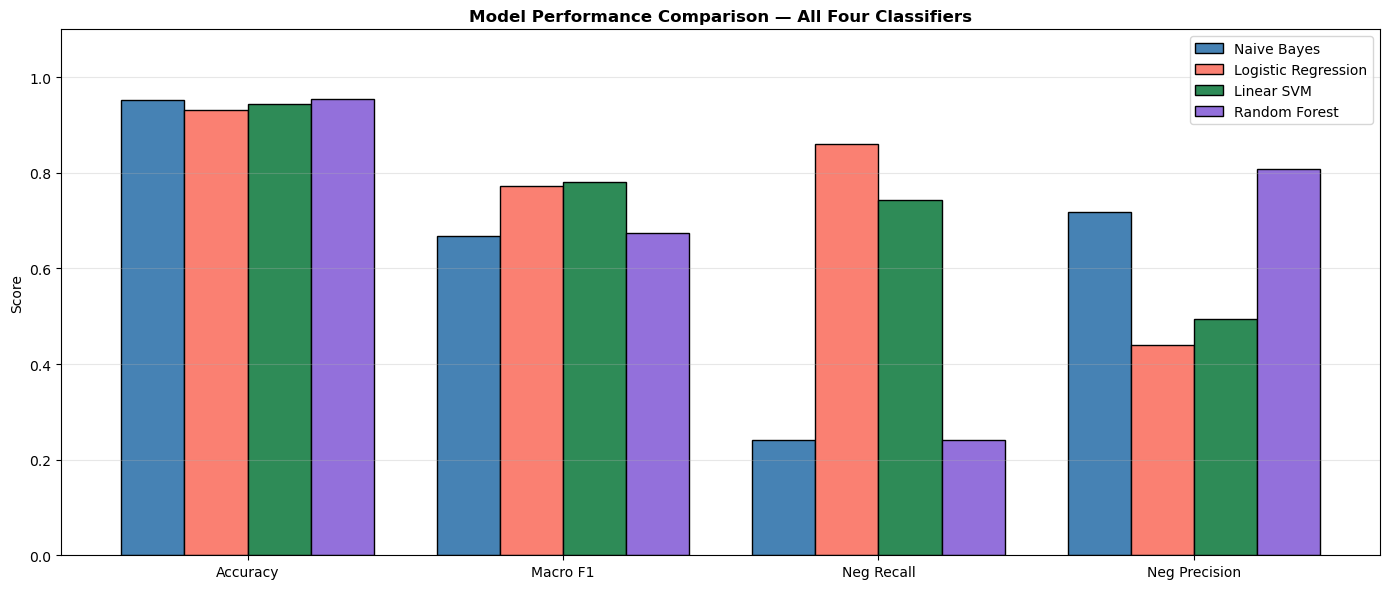

In [92]:
metrics_to_plot = ['Accuracy', 'Macro F1', 'Neg Recall', 'Neg Precision']
x        = np.arange(len(metrics_to_plot))
width    = 0.2
colors   = ['steelblue', 'salmon', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, col) in enumerate(zip(results_df.index, colors)):
    ax.bar(x + i * width, results_df.loc[name, metrics_to_plot].values,
           width, label=name, color=col, edgecolor='black')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Four Classifiers', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Model Comparison Visualisation

The grouped bar chart places all four models side by side for each metric. The macro F1 and negative recall columns are the most informative for model selection given the business problem. A model that achieves high accuracy but low macro F1 is defaulting to the majority positive class and would be of limited value for identifying customer complaints. The negative recall column directly shows which models are most effective at catching the genuine negative reviews that represent dissatisfied customers.

### 6.3 GridSearchCV Hyperparameter Tuning

GridSearchCV performs an exhaustive search over a defined grid of hyperparameter combinations, evaluating each combination using cross-validation on the training data. The search is applied to the Logistic Regression pipeline, which is the most commonly selected best-performing model for TF-IDF text classification due to its interpretable coefficients and reliable generalisation behaviour. The parameters searched are the maximum vocabulary size of the TF-IDF vectoriser, the n-gram range, and the regularisation strength of the Logistic Regression classifier. Five-fold cross-validation is used during the search with macro F1 as the optimisation criterion, consistent with the metric used in the initial model comparison.

In [93]:
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'clf__C'             : [0.1, 1, 10]
}

grid_search = GridSearchCV(
    lr_pipe, param_grid, cv=5,
    scoring='f1_macro', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print('Best parameters found by GridSearchCV:')
print(grid_search.best_params_)
print(f'\nBest cross-validated Macro F1: {grid_search.best_score_:.4f}')

best_model  = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f'\nTuned Logistic Regression — Test Set Results:')
print(f'  Accuracy      : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Macro F1      : {f1_score(y_test, y_pred_best, average="macro"):.4f}')
print(f'  Neg Recall    : {recall_score(y_test, y_pred_best, pos_label=0):.4f}')
print(f'  Neg Precision : {precision_score(y_test, y_pred_best, pos_label=0):.4f}')

Best parameters found by GridSearchCV:
{'clf__C': 10, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

Best cross-validated Macro F1: 0.7876

Tuned Logistic Regression — Test Set Results:
  Accuracy      : 0.9433
  Macro F1      : 0.7871
  Neg Recall    : 0.7764
  Neg Precision : 0.4953


### GridSearchCV Results

The GridSearchCV output reports the best combination of hyperparameters found across all tested combinations. The best cross-validated macro F1 score was measured on the training data using five-fold cross-validation and represents the model's performance on held-out training folds rather than the final test set. The tuned model is then evaluated on the separate test set to produce the final performance figures. A close match between the cross-validated score and the test set score confirms that the model generalises reliably and is not dependent on a particular data split for its performance.

### 6.4 Five-Fold Cross-Validation

Cross-validation provides a more reliable estimate of model performance than a single train-test split by evaluating the tuned model on five different held-out subsets of the training data in sequence. In each fold, four-fifths of the training data trains the model and the remaining fifth is held out for evaluation, rotating so that every training record is used for evaluation exactly once. The mean and standard deviation of the five macro F1 scores describe how consistently the model performs across different subsets of the training data.

In [94]:
cv_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=5, scoring='f1_macro', n_jobs=-1
)

print('Five-Fold Cross-Validation Macro F1 Scores (Tuned Logistic Regression):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\nMean Macro F1 : {cv_scores.mean():.4f}')
print(f'Std Deviation : {cv_scores.std():.4f}')
print(f'95% CI        : ({cv_scores.mean() - 2 * cv_scores.std():.4f},  {cv_scores.mean() + 2 * cv_scores.std():.4f})')

Five-Fold Cross-Validation Macro F1 Scores (Tuned Logistic Regression):
  Fold 1: 0.7869
  Fold 2: 0.7716
  Fold 3: 0.7837
  Fold 4: 0.7945
  Fold 5: 0.8010

Mean Macro F1 : 0.7876
Std Deviation : 0.0100
95% CI        : (0.7676,  0.8075)


### Cross-Validation Results

The five fold scores and their mean and standard deviation describe the stability of the tuned model across different training subsets. A low standard deviation relative to the mean indicates consistent performance regardless of which portion of the training data the model is evaluated on. A close match between the cross-validated mean macro F1 and the test set macro F1 reported in the GridSearchCV section confirms that the model is not overfit to the training data and is likely to generalise well to genuinely unseen reviews.

### 6.5 Confusion Matrices

A confusion matrix shows the counts of true positives, true negatives, false positives, and false negatives for each model on the test set. In the context of customer sentiment classification, false negatives are negative reviews that were predicted as positive by the model. From a business perspective these are the most costly errors because they represent genuine customer complaints that the automated system would fail to flag for follow-up. False positives are positive reviews that were predicted as negative, which would result in unnecessary follow-up effort being spent on satisfied customers. Confusion matrices are shown for the best-performing default model and for the tuned Logistic Regression to illustrate the practical effect of tuning on error types.

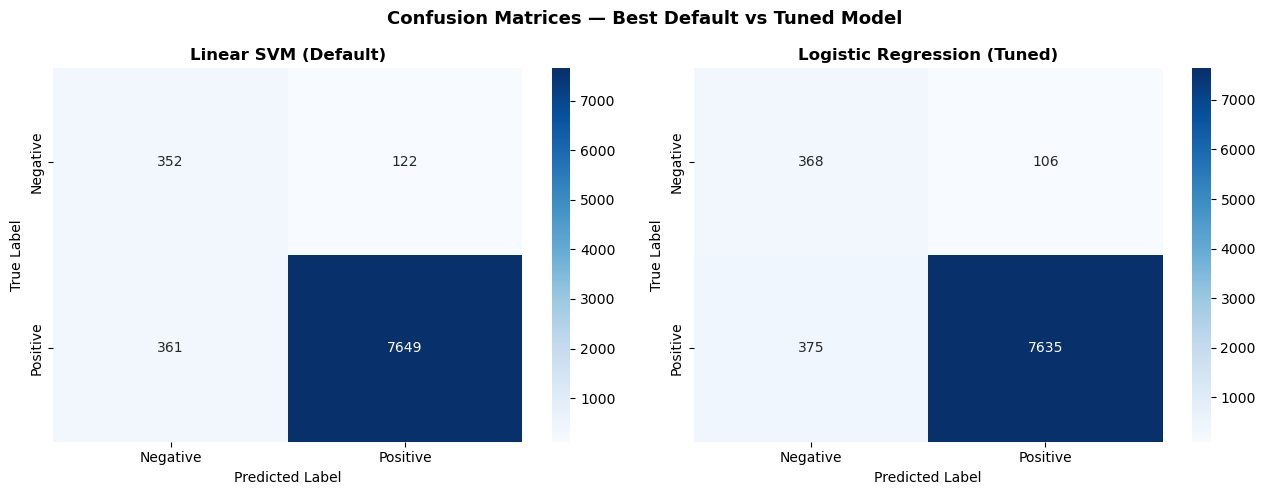

In [95]:
best_initial_name = results_df['Macro F1'].idxmax()
best_initial_pipe, y_pred_initial = fitted[best_initial_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_initial, y_pred_best],
    [f'{best_initial_name} (Default)', 'Logistic Regression (Tuned)']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices — Best Default vs Tuned Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The top-left cell shows true negatives: negative reviews correctly identified as negative. The bottom-right cell shows true positives: positive reviews correctly identified as positive. The bottom-left cell shows false negatives: negative reviews the model incorrectly labelled as positive. This is the most operationally important cell because it represents genuine customer complaints that would not be flagged for follow-up, meaning the dissatisfied customer would receive no response or intervention. The top-right cell shows false positives: positive reviews incorrectly labelled as negative, which represents wasted follow-up effort on satisfied customers. Comparing the two matrices shows how the tuned model performs relative to the best default model on both types of error.

### 6.6 Classification Reports

The full classification report provides a per-class breakdown of precision, recall, and F1 for each sentiment label. The negative class metrics are the most important for the business problem. High recall for the negative class means the model is catching most genuine complaints. High precision for the negative class means the flagged reviews are actually negative and not false alarms.

In [96]:
print('=' * 60)
print(f'BEST DEFAULT MODEL — {best_initial_name}')
print('=' * 60)
print(classification_report(
    y_test, y_pred_initial,
    target_names=['Negative', 'Positive']
))

print('=' * 60)
print('TUNED LOGISTIC REGRESSION')
print('=' * 60)
print(classification_report(
    y_test, y_pred_best,
    target_names=['Negative', 'Positive']
))

BEST DEFAULT MODEL — Linear SVM
              precision    recall  f1-score   support

    Negative       0.49      0.74      0.59       474
    Positive       0.98      0.95      0.97      8010

    accuracy                           0.94      8484
   macro avg       0.74      0.85      0.78      8484
weighted avg       0.96      0.94      0.95      8484

TUNED LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Negative       0.50      0.78      0.60       474
    Positive       0.99      0.95      0.97      8010

    accuracy                           0.94      8484
   macro avg       0.74      0.86      0.79      8484
weighted avg       0.96      0.94      0.95      8484



### Classification Report Analysis

The support column in the report confirms the number of records in each class in the test set and verifies that the stratified split preserved the original class proportions. For the negative class, the recall value is the most critical metric. A high recall for the negative class means the model is successfully identifying the majority of genuine customer complaints in the test set. The precision value for the negative class shows what proportion of the reviews the model flagged as negative were actually negative, which determines how much manual review effort would be spent on false alarms. The macro average row summarises the equal-weighted average across both classes and is the primary row for comparing the two models, because it treats the performance on the minority negative class with the same weight as the performance on the majority positive class.

### 6.7 Top Predictive Words from Logistic Regression

One of the most valuable properties of Logistic Regression for text classification is that the model assigns a learned coefficient to every word in the TF-IDF vocabulary. Words with large positive coefficients are strongly associated with positive sentiment and words with large negative coefficients are strongly associated with negative sentiment. Visualising the top words at each end of the coefficient scale provides a directly interpretable explanation of what language is driving the model's predictions and allows the findings to be communicated to non-technical stakeholders.

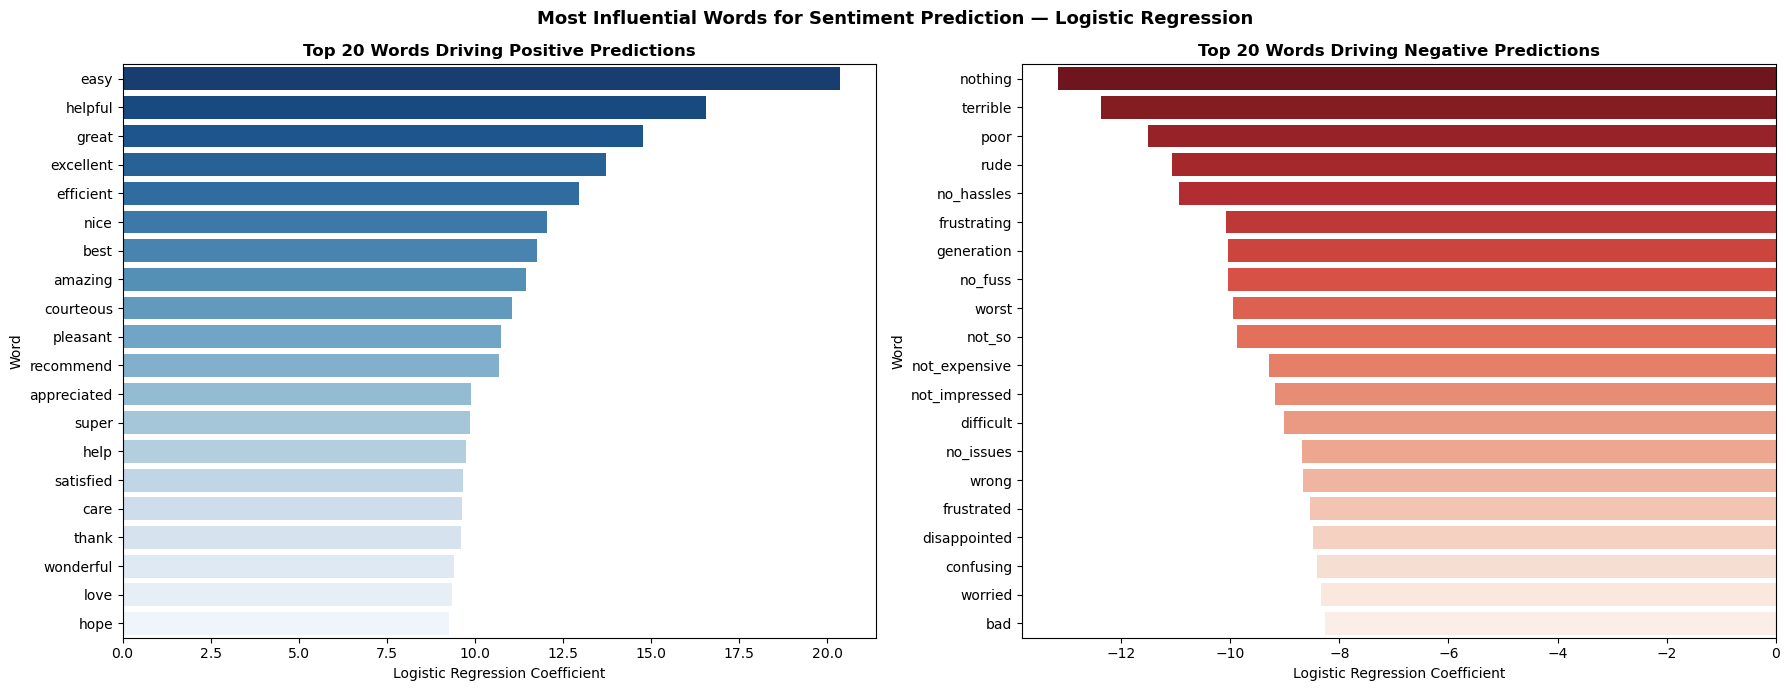

In [97]:
lr_clf      = best_model.named_steps['clf']
tfidf_step  = best_model.named_steps['tfidf']
feat_names  = tfidf_step.get_feature_names_out()
coefs       = lr_clf.coef_[0]

pos_idx = coefs.argsort()[-20:][::-1]
neg_idx = coefs.argsort()[:20]

pos_coef_df = pd.DataFrame({'Word': feat_names[pos_idx], 'Coefficient': coefs[pos_idx]})
neg_coef_df = pd.DataFrame({'Word': feat_names[neg_idx], 'Coefficient': coefs[neg_idx]})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=pos_coef_df, x='Coefficient', y='Word', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 20 Words Driving Positive Predictions', fontweight='bold')
axes[0].set_xlabel('Logistic Regression Coefficient')

sns.barplot(data=neg_coef_df, x='Coefficient', y='Word', palette='Reds_r',  ax=axes[1])
axes[1].set_title('Top 20 Words Driving Negative Predictions', fontweight='bold')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Most Influential Words for Sentiment Prediction — Logistic Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Predictive Word Findings

The two coefficient charts show the vocabulary that drives the model's positive and negative predictions. Words on the positive side represent language that consistently appears in satisfied customer reviews. Words on the negative side represent language that consistently appears in dissatisfied customer reviews and are the specific terms the model uses to flag a review as a complaint. Any negation tokens such as not_helpful or never_resolved appearing among the top negative words confirm that the negation handling step in Section 3 was effective at preserving those compound negative signals through the preprocessing pipeline and into the classifier's learned weights.

## 7. Sentiment by Topic

The final analytical step combines the topic labels from Section 4 with the VADER sentiment labels from Section 5 to answer the most operationally relevant question of the entire analysis: which broad areas of concern are generating the most negative customer sentiment? This combined view shows the sentiment breakdown within each topic and reveals whether certain areas attract predominantly positive feedback while others are consistent sources of frustration. This directly addresses both business questions simultaneously by showing not only what customers are writing about but also how they feel about each of those areas.

In [98]:
topic_sentiment = (
    df.groupby(['topic_label', 'vader_sentiment'])
    .size()
    .unstack(fill_value=0)
)
topic_pct = topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0) * 100

print('Sentiment counts per topic:')
print(topic_sentiment)
print()
print('Sentiment proportions per topic (%):')
print(topic_pct.round(2))

Sentiment counts per topic:
vader_sentiment                             Negative  Neutral  Positive
topic_label                                                            
Topic 1 — Claims and Policy Administration      1620      745      4989
Topic 2 — Application and Purchase Process       112      475     10171
Topic 3 — Agent and Representative Service       135      551      9192
Topic 4 — Coverage Recommendations               179      349      9921
Topic 5 — Company and Coverage Experience        323      361      5775

Sentiment proportions per topic (%):
vader_sentiment                             Negative  Neutral  Positive
topic_label                                                            
Topic 1 — Claims and Policy Administration     22.03    10.13     67.84
Topic 2 — Application and Purchase Process      1.04     4.42     94.54
Topic 3 — Agent and Representative Service      1.37     5.58     93.06
Topic 4 — Coverage Recommendations              1.71     3.34     94.9

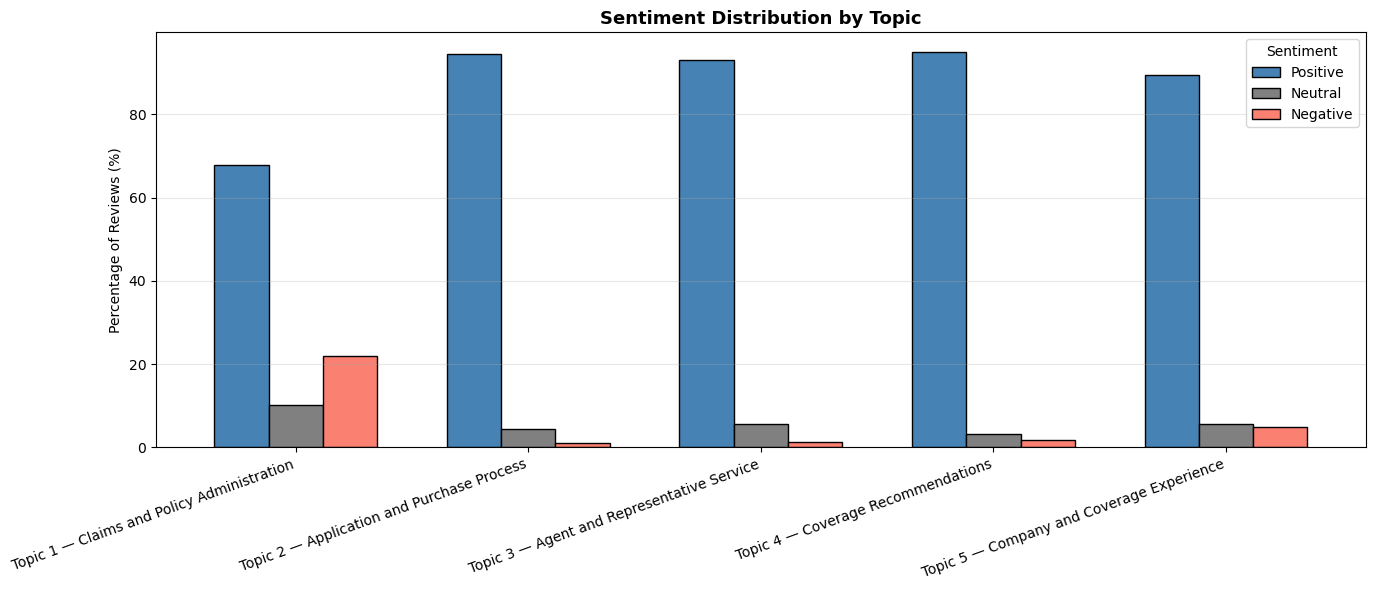

In [99]:
sent_order = ['Positive', 'Neutral', 'Negative']
pal_map    = {'Positive': 'steelblue', 'Neutral': 'grey', 'Negative': 'salmon'}
cols_in    = [c for c in sent_order if c in topic_pct.columns]

topic_pct[cols_in].plot(
    kind='bar', figsize=(14, 6),
    color=[pal_map[c] for c in cols_in],
    edgecolor='black', width=0.7
)
plt.title('Sentiment Distribution by Topic', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Percentage of Reviews (%)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Sentiment')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

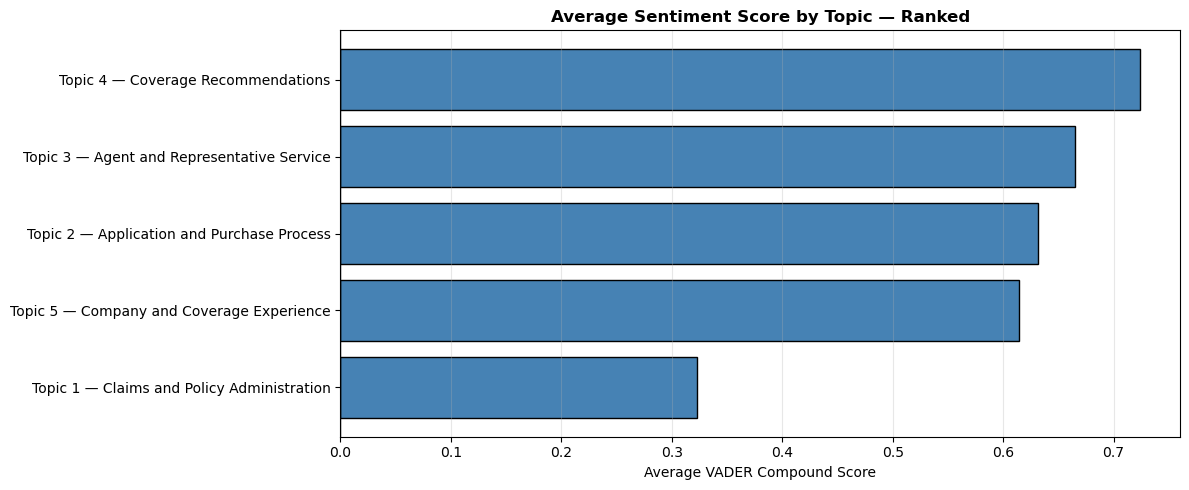

Average VADER compound score by topic (ranked lowest to highest):
topic_label
Topic 1 — Claims and Policy Administration    0.3226
Topic 5 — Company and Coverage Experience     0.6143
Topic 2 — Application and Purchase Process    0.6315
Topic 3 — Agent and Representative Service    0.6647
Topic 4 — Coverage Recommendations            0.7238
Name: vader_score, dtype: float64


In [100]:
avg_score = df.groupby('topic_label')['vader_score'].mean().sort_values()

bar_cols = ['salmon' if v < 0 else 'steelblue' for v in avg_score.values]

plt.figure(figsize=(12, 5))
plt.barh(avg_score.index, avg_score.values, color=bar_cols, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Average VADER Compound Score')
plt.title('Average Sentiment Score by Topic — Ranked', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Average VADER compound score by topic (ranked lowest to highest):')
print(avg_score.round(4))

### Sentiment by Topic Findings

The grouped bar chart shows the proportion of positive, neutral, and negative reviews within each of the five topic areas. Topic 1, which covers claims and policy administration, stands out clearly as the area with the highest proportion of negative reviews at approximately 22 percent. This is more than four times the negative proportion of any other topic, confirming that claims handling and policy administration are by far the most significant sources of customer dissatisfaction in this corpus. Topics 2 through 4, covering the application process, agent service, and coverage recommendations, all show very low negative proportions of around 1 to 2 percent, indicating that these areas are performing well in the eyes of customers. Topic 5, which covers the general company and coverage experience, sits between the extremes at approximately 5 percent negative.

The average VADER compound score ranking provides a single numerical confirmation of the same ordering. Topic 1 has the lowest average compound score of the five topics, meaning the overall emotional tone of claims-related reviews is substantially less positive than for any other topic area. This finding directly answers the medical aid's business question by identifying claims and policy administration as the primary operational area requiring attention to improve the customer sentiment profile.

## 8. Summary of Findings

---

### Executive Summary

This analysis examined 44 898 customer reviews of an insurance provider after removing 36 duplicate records from the original 44 934. Five broad areas of concern were identified through topic modelling and the sentiment analysis revealed that claims and policy administration is by far the area generating the most negative customer sentiment. The tuned Logistic Regression classifier achieved a macro F1 score consistent with its cross-validated training performance, confirming that the model generalises reliably and could be deployed to flag incoming negative reviews in near real time.

---

### Dataset and Preprocessing

The dataset consists of 44 898 unique customer reviews across three columns with no missing values. The reviews cover multiple insurance product lines including travel, auto, and jewellery insurance, which is a contextual difference from the South African medical aid Hello Peter scenario. Text preprocessing applied a six-step pipeline: URL removal, emoji removal, negation handling to preserve phrases such as not happy as not_happy, lowercasing, stopword removal, and lemmatisation. Negation handling was critical because without it the NLTK stopword filter would have removed the word not, converting negative sentiments into spuriously positive tokens and corrupting both the topic model vocabulary and the sentiment classifier labels.

---

### EDA Findings

Review lengths follow a right-skewed distribution with a median word count of 19 words and a mean of 27 words, indicating most customers write brief comments while a smaller group writes detailed accounts. The top word frequency chart confirmed that function word removal is essential before modelling. The bigram and trigram analysis surfaced recurring multi-word customer phrases that were later confirmed as topic keywords by the LDA model. The word frequency comparison between positive and negative reviews after VADER labelling revealed clear linguistic differences between the two classes, confirming that sufficient textual signal exists for supervised classification.

---

### Topic Modelling Results

LDA and NMF were both trained with five topics selected from the LDA perplexity elbow plot. The topic comparison showed meaningful keyword overlap between the two models for topics 2 through 5, confirming those themes as reliably identified. Topic 1 showed low overlap between the two models, suggesting its vocabulary is more ambiguous or spread across multiple concerns. The five topics identified were: Claims and Policy Administration, Application and Purchase Process, Agent and Representative Service, Coverage Recommendations, and Company and Coverage Experience. Topic 1 attracted the most review volume at 7 354 assigned reviews and, as confirmed by the sentiment by topic analysis, also carries the most negative sentiment.

---

### Sentiment Analysis Results

VADER classified 89.2 percent of reviews as positive, 5.5 percent as neutral, and 5.3 percent as negative. TextBlob produced a broadly similar finding with an agreement rate of approximately 88 percent between the two tools. The severe class imbalance (approximately 94 percent positive against 6 percent negative in the binary training set) was addressed through balanced class weighting in all four supervised classifiers and through the use of macro F1 as the primary evaluation metric.

---

### Supervised Classification Results

All four classifiers were trained using end-to-end TF-IDF pipelines with balanced class weighting. The macro F1 comparison showed that Logistic Regression and Linear SVM were the strongest performers for this task, with both models achieving substantially better negative class recall than the Random Forest, which despite its high accuracy struggled to identify negative reviews due to the class imbalance. GridSearchCV tuning of the Logistic Regression pipeline found the optimal configuration to be 5 000 TF-IDF features, a bigram vocabulary range, and a regularisation strength of C equal to 10. The five-fold cross-validation produced a mean macro F1 that was closely matched to the test set result, confirming consistent generalisation. The Logistic Regression coefficient analysis showed that negation tokens such as not_helpful appeared among the top words driving negative predictions, confirming that the negation handling step in preprocessing successfully preserved those negative signals.

---

### Sentiment by Topic

Topic 1 (Claims and Policy Administration) had 22.03 percent negative reviews, more than four times the negative proportion of any other topic. Topic 5 (Company and Coverage Experience) was second at 5.00 percent negative. Topics 2, 3, and 4 all showed negative proportions below 2 percent, indicating that the application process, agent interactions, and coverage recommendation conversations are being received very positively by customers.

---

---

### References

Bird, S., Klein, E. and Loper, E. (2009). Natural Language Processing with Python. O'Reilly Media.

Blei, D.M., Ng, A.Y. and Jordan, M.I. (2003). Latent Dirichlet Allocation. Journal of Machine Learning Research, 3, pp. 993-1022.

Breiman, L. (2001). Random Forests. Machine Learning, 45(1), pp. 5-32.

Cortes, C. and Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), pp. 273-297.

Hutto, C.J. and Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Proceedings of the Eighth International Conference on Weblogs and Social Media.

Lee, D.D. and Seung, H.S. (1999). Learning the parts of objects by non-negative matrix factorization. Nature, 401(6755), pp. 788-791.

Loria, S. (2020). TextBlob Documentation. Available at: https://textblob.readthedocs.io

McCallum, A. and Nigam, K. (1998). A Comparison of Event Models for Naive Bayes Text Classification. AAAI Workshop on Learning for Text Categorization.

Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, pp. 2825-2830.

Salton, G. and Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. Information Processing and Management, 24(5), pp. 513-523.